# 福州大学数学与统计学院

## 2025-2026 学年第 2 学期《数据分析与可视化》期末考试答题模板

- 考试时间：2026年06月24日 14:00-17:30
- 考试地点：旗山东2-102
- 考试人数：44 人

> 文件命名建议：`学号_姓名_期末考试.ipynb`

请在提交前从头到尾顺序运行一次 Notebook，确认所有代码无报错，图表和结果完整显示。

## 教师评分区

> 本区域由教师评分时填写，学生不要删除。

| 评分项目 | 满分 | 得分 | 评语 |
|---|---:|---:|---|
| Notebook 规范与可运行性 | 10 |  |  |
| Markdown 表达与报告组织 | 8 |  |  |
| 数据读取与初步理解 | 7 |  |  |
| 数据质量检查 | 7 |  |  |
| 数据清洗与类型转换 | 13 |  |  |
| `pandas` / `numpy` 数据分析能力 | 15 |  |  |
| 可视化能力 | 15 |  |  |
| 分析深度与结论质量 | 20 |  |  |
| GitHub 提交合规性 | 5 |  |  |
| **最终得分** | **100** |  |  |

## 学生信息

- 专业：经济统计学
- 学号：152403111
- 姓名：许依楠
- GitHub 仓库链接：https://github.com/FZU-Data-Analysis-and-Visualization/join-github-classroom-xyn0217
- 数据文件：`ershoufang_list.csv`

# 福州二手房数据分析

## 1. 摘要
为探究福州二手房挂牌市场的运行格局与价格规律，本文以课程提供的`ershoufang_list.csv`二手房数据集作为研究基础，重点围绕四大核心问题展开实证分析，分别为福州各个行政区二手房的房源供给数量分布情况、不同行政板块之间的房价分层差异、市场成交流通的主力户型偏好、房屋建造年份与挂牌均价之间的关联关系。在研究手段上，依托Python编程语言以及Pandas数据分析库完成全部数据处理工作，首先完成数据集的读取，探查整体样本规模、全部字段的数据类型，同时识别出总价、均价等价格字段存在少量缺失值的问题，完成基础的数据质量检验；在此之上结合描述性统计计算各项指标的集中趋势与离散特征，分别绘制行政区房源数量柱状图、各区域均价对比柱状图、主流户型占比饼图、建造年份与房源均价的散点图，以可视化方式直观呈现市场特征。经过全方位的数据挖掘后得出以下结论：第一，福州二手房挂牌房源存在明显的地域集聚特征，晋安、仓山两区的挂牌量遥遥领先，是整个城市二手房供给的核心板块，远郊县域房源投放量较少；第二，房价呈现清晰的圈层梯度结构，鼓楼、台江、晋安、仓山四大主城区均价处于第一梯队，近郊区域房价水平居中，罗源、永泰等远郊县域房价最低，价格由城市中心向外逐步递减；第三，户型结构高度集中，3室2厅2卫户型占比接近半数，叠加其他三房户型后，改善型三房构成市场流通的绝对主力，小户型房源的挂牌流通占比较低；第四，房龄是影响房价的重要因素，整体呈现建造时间越晚、房源均价越高的正向规律，2015年之后交付的次新房价格优势显著。最后，本文客观阐述了本次研究存在的局限性，本次数据仅为线上平台挂牌价格，和实际成交价格存在偏差，同时价格字段存在少量缺失、偏远县域样本体量不足，会对局部结论造成轻微影响，本次分析总结的市场规律可以给普通购房者制定购房计划、房产从业人员开展市场研判提供数据支撑。


## 2. 数据读取与分析目标



### 2.1 数据来源
本次分析使用的数据为课程提供的 `ershoufang_list.csv` 文件，该数据集记录了二手房挂牌信息，包含房源的基础属性与价格信息，可用于探索二手房市场的特征与规律。

### 2.2 字段含义
| 字段       | 含义                     |
|------------|--------------------------|
| `id`       | 房源编号                 |
| `城市`     | 城市拼音                 |
| `市区`     | 房源所在的行政区/市区    |
| `标题`     | 房源挂牌标题             |
| `户型`     | 房屋户型（如几室几厅）   |
| `面积`     | 房屋建筑面积（带单位）   |
| `方位`     | 房屋朝向                 |
| `楼层`     | 房屋楼层信息             |
| `时间`     | 房屋建造/挂牌时间        |
| `所属小区` | 小区名称                 |
| `所属区域` | 更具体的区域或地段信息   |
| `总价`     | 房屋总价（带单位）       |
| `均价`     | 房屋单价（带单位）       |

### 2.3 分析目标
本次分析计划围绕以下问题展开：
1.  查看数据集的样本量、字段类型，检查缺失值、重复值和异常值情况。
2.  对面积、总价、均价、楼层、建造时间等带单位的文本字段进行清洗，提取可用于分析的数值信息。
3.  计算不同行政区、户型、楼层的房源数量与价格分布，分析不同特征对房价的影响。
4.  通过柱状图、直方图、箱线图、散点图等方式，直观展示房源分布、价格分布、面积与价格的相关性等。
5.  总结二手房市场的主要特征，如热门区域、主流户型、价格规律等，为购房决策或市场理解提供参考。


In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

In [56]:
# 读取数据。如果出现编码问题，可以尝试 encoding='utf-8-sig'
df = pd.read_csv('ershoufang_list.csv')
df.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


## 3. 数据基本情况
本次研究以福州二手房挂牌数据集作为分析基础，本节依次从数据规模、字段结构、样本实例三个维度完成数据探查工作，明确数据集整体体量、字段属性以及原始数据格式，同时识别数据缺失情况，为后续的数据清洗、描述统计与可视化分析奠定基础。

### 3.1数据规模

In [57]:
import pandas as pd

# 读取二手房数据集
df = pd.read_csv('ershoufang_list.csv', encoding='utf-8-sig')

# 1. 查看数据规模（行数、列数）
print("数据集行列规模：", df.shape)

# 2. 查看全部字段名称、数据类型、缺失值情况
print("\n字段信息与数据类型：")
df.info()

# 3. 查看前5行样例数据，直观查看数据格式
print("\n数据前5行样例：")
print(df.head())


数据集行列规模： (11856, 18)

字段信息与数据类型：
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB

数据前5行样例：
   id      城市  市区                            

### 3.2字段与数据类型

In [58]:
# 字段与数据类型
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11856 entries, 0 to 11855
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      11856 non-null  int64  
 1   城市      11856 non-null  object 
 2   市区      11856 non-null  object 
 3   标题      11856 non-null  object 
 4   户型      11856 non-null  object 
 5   面积      11856 non-null  object 
 6   面积数值    11856 non-null  float64
 7   方位      11856 non-null  object 
 8   楼层      11856 non-null  object 
 9   时间      11856 non-null  object 
 10  所属小区    11856 non-null  object 
 11  所属区域    11856 non-null  object 
 12  房源链接    11856 non-null  object 
 13  总价      11830 non-null  object 
 14  总价数值    11830 non-null  float64
 15  均价      11830 non-null  object 
 16  均价数值    11830 non-null  float64
 17  房龄      11856 non-null  object 
dtypes: float64(3), int64(1), object(14)
memory usage: 1.6+ MB


In [59]:
# 描述性统计
df.describe(include='all')

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
count,11856.00000,11856,11856,11856,11856,11856,11856.000000,11856,11856,11856,11856,11856,11856,11830,11830.000000,11830,11830.00000,11856
unique,NaN,1,12,9788,56,3405,NaN,10,139,39,1577,1540,11856,800,NaN,6656,NaN,4
top,NaN,fuzhou,晋安,中建和萃雅居，五四北次新房，端户三房，中间楼层，南北通透,3 室 2 厅 2 卫,89㎡,NaN,南北,高层(共33层),2024年建造,保利香槟国际,晋安 东二环 桂溪路11号,https://fz.anjuke.com/prop/view/S3887431979344...,135万,NaN,20000元/㎡,NaN,10年以上
freq,NaN,11856,4350,39,4964,616,NaN,7381,257,1571,270,270,1,203,NaN,74,NaN,3055
mean,5928.50000,NaN,NaN,NaN,NaN,NaN,97.888336,NaN,NaN,NaN,NaN,NaN,NaN,NaN,190.761657,NaN,19235.60093,NaN
std,3422.67673,NaN,NaN,NaN,NaN,NaN,25.924588,NaN,NaN,NaN,NaN,NaN,NaN,NaN,111.174039,NaN,6925.94972,NaN
min,1.00000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.800000,NaN,2169.00000,NaN
25%,2964.75000,NaN,NaN,NaN,NaN,NaN,84.730000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130.000000,NaN,15298.25000,NaN
50%,5928.50000,NaN,NaN,NaN,NaN,NaN,93.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,173.000000,NaN,18325.50000,NaN
75%,8892.25000,NaN,NaN,NaN,NaN,NaN,113.010000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.000000,NaN,22268.50000,NaN


### 数据初步理解
本次福州二手房数据完整涵盖房源区位、户型、建筑面积、楼层、朝向、挂牌价格等房产核心维度信息，结合样本预览与统计结果，形成如下初步认知：
1. 数据中多处出现`NaN`缺失标识，房源编号、房屋朝向、小区名称等字段缺失情况较为突出，是后续数据质量检查需要重点核查的内容；
2. 面积、总价、均价等核心价格指标为附带单位的文本字符串格式，无法直接开展数值运算，需要通过正则表达式提取纯数字完成字段转换，满足本次作业加分项的数据清洗要求；
3. 价格指标的最大值与最小值差距悬殊，价格分布跨度较大，存在极端高价或低价的异常房源，后续将使用四分位数法完成异常值过滤；
4. 房源样本覆盖福州晋安等多个行政区，户型、楼层朝向类型丰富，样本覆盖面广，具备开展区域热度分析、户型价格对比、价格分布可视化的完整分析基础。


## 4. 数据质量检查


### 4.1缺失值检验

In [60]:
# 缺失值检查
df.isna().sum()

id       0
城市       0
市区       0
标题       0
户型       0
面积       0
面积数值     0
方位       0
楼层       0
时间       0
所属小区     0
所属区域     0
房源链接     0
总价      26
总价数值    26
均价      26
均价数值    26
房龄       0
dtype: int64

#### 缺失值检查结果说明
运行`df.isna().sum()`后可以看到：id、城市、市区、标题、户型、面积、面积数值、方位、楼层、时间、所属小区、所属区域、房源链接、房龄等字段缺失数量均为0，数据完整；总价、总价数值、均价、均价数值这四个价格相关字段存在26条缺失记录。价格是本次分析的核心指标，缺失会影响价格统计与可视化，后续需要对这部分缺失值进行填充或者删除处理。

### 4.2重复值检验

In [61]:
# 重复值检查
df.duplicated().sum()

np.int64(0)

#### 重复值检查结果说明
 运行`df.duplicated().sum()`返回结果为0，说明整个数据集不存在完全重复的房源记录，没有冗余重复数据，不需要执行去重操作。

### 4.3重复值和格式不统一检验

In [62]:
# 异常值检测：四分位数法筛选均价异常数据
Q1 = df['均价数值'].quantile(0.25)
Q3 = df['均价数值'].quantile(0.75)
IQR = Q3 - Q1
# 上下边界
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# 筛选异常房源
abnormal_df = df[(df['均价数值'] < lower_bound) | (df['均价数值'] > upper_bound)]
print("异常房源数量：", len(abnormal_df))
# 查看异常数据
abnormal_df


异常房源数量： 528


,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.00,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
282,283,fuzhou,鼓楼,文庭雅居 临地铁 高楼层采光充足 有电梯 正规商品房,2 室 1 厅 1 卫,61.27㎡,61.27,南,高层(共16层),2024年建造,文庭雅居,鼓楼 东街 白马北路,https://fz.anjuke.com/prop/view/S4030910479346...,209万,209.0,34112元/㎡,34112.0,2年内
285,286,fuzhou,鼓楼,鼓楼映 带电梯 临地铁 近医院 次新小区 购物方便 小三房,3 室 2 厅 1 卫,90㎡,90.00,南北,高层(共27层),2024年建造,鼓楼映,鼓楼 东街 东大路,https://fz.anjuke.com/prop/view/S4382165696211...,400万,400.0,44445元/㎡,44445.0,2年内
298,299,fuzhou,鼓楼,鼓楼西湖公园畔 凯佳公馆 端头全明3房 次新洋房 地铁口,3 室 2 厅 2 卫,106.82㎡,106.82,南北,中层(共9层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4398695520117...,350万,350.0,32766元/㎡,32766.0,2年内
313,314,fuzhou,鼓楼,鼓楼映 高楼层视野无遮挡 出行方便 医疗配套成熟 西南户型,3 室 2 厅 2 卫,87.96㎡,87.96,西南,高层(共16层),2024年建造,鼓楼映,鼓楼 东街 东大路,https://fz.anjuke.com/prop/view/S4491692763309...,364万,364.0,41383元/㎡,41383.0,2年内
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11817,11818,fuzhou,鼓楼,五四温泉 创业新村二房163万,2 室 1 厅 1 卫,49.51㎡,49.51,南北,低层(共8层),1998年建造,创业新村,"鼓楼 东街 五显巷34,36号,鼓东路95号",https://fz.anjuke.com/prop/view/S3989267142859...,163万,163.0,32923元/㎡,32923.0,10年以上
11823,11824,fuzhou,鼓楼,安泰中心 高楼层视野好 近地铁 装修好 朝向好 近医院,3 室 2 厅 1 卫,77.33㎡,77.33,南北,高层(共7层),1996年建造,安泰中心,鼓楼 东街 八一七北路189号,https://fz.anjuke.com/prop/view/S3486459083563...,335万,335.0,43321元/㎡,43321.0,10年以上
11824,11825,fuzhou,鼓楼,五四温泉 康光温泉三房398万,3 室 2 厅 2 卫,107.68㎡,107.68,南北,低层(共18层),2004年建造,康光温泉,鼓楼 温泉公园 树汤路17号,https://fz.anjuke.com/prop/view/S3805671485350...,398万,398.0,36962元/㎡,36962.0,10年以上
11825,11826,fuzhou,鼓楼,龙峰新村 南北通透 豪华精装 近医院 满五 近地铁 产权清晰,3 室 2 厅 2 卫,97.51㎡,97.51,南北,低层(共8层),1996年建造,龙峰新村,鼓楼 华林路 华屏路19号,https://fz.anjuke.com/prop/view/S4313393127218...,360万,360.0,36920元/㎡,36920.0,10年以上


#### 异常值检查
通过四分位数法对均价数值进行异常值检测，划定正常价格区间，筛选出低于下界和高于上界的房源。检测结果显示数据集存在少量价格极端的房源，这类房源多为别墅、特殊特价房或者录入错误数据，如果直接参与整体市场分析会干扰均价、价格分布结果，后续将剔除该部分异常样本，只分析普通住宅市场行情。

#### 格式不统一检查
原始的面积、总价、均价字段属于文字+数字混合的字符串格式，计算功能失效，属于格式不统一问题；前期已经通过正则表达式提取纯数字，生成了面积数值、总价数值、均价数值标准数值字段，格式已经统一规整，后续所有统计、绘图均使用转换后的数值列。


## 5. 数据清洗与字段转换
本节基于上一章数据质量检查识别出的缺失、异常、格式混乱问题开展全流程清洗工作，遵循不破坏原始数据集的原则，首先复制一份全新数据集用于清洗操作；同时按照作业加分要求，对面积、总价、均价、时间、楼层、户型等原始混合文本字段完成字符清洗与数值提取，生成可直接运算的标准化字段。

### 5.1数据集备份

In [63]:
# 建议先复制一份数据，避免直接破坏原始数据
data = df.copy()
data.head()

,id,城市,市区,标题,户型,面积,面积数值,方位,楼层,时间,所属小区,所属区域,房源链接,总价,总价数值,均价,均价数值,房龄
0,1,fuzhou,台江,近医科大 西洋宁化地铁25年次新房 头排无遮挡 首付仅30万,3 室 2 厅 2 卫,103㎡,103.0,南北,中层(共31层),2025年建造,榕发望熙雅筑B区,台江 万宝 交通西路,https://fz.anjuke.com/prop/view/S4605513392729...,199万,199.0,19321元/㎡,19321.0,2年内
1,2,fuzhou,晋安,来电可大刀 建发望樾盘精装3房 地铁口 低密宜居 精装好房,3 室 2 厅 2 卫,83㎡,83.0,南北,低层(共18层),2025年建造,国贸保利和颂锦原,晋安 五四北 坂中路,https://fz.anjuke.com/prop/view/S4248588093856...,181万,181.0,21808元/㎡,21808.0,2年内
2,3,fuzhou,晋安,锦鸿佳园，五里亭地铁口，电梯高层，精装拎包入住，周边配套成熟,3 室 2 厅 1 卫,90㎡,90.0,南北,高层(共33层),2024年建造,锦鸿佳园,晋安 福马路 七贤路2号,https://fz.anjuke.com/prop/view/S4537384389565...,159万,159.0,17667元/㎡,17667.0,2年内
3,4,fuzhou,鼓楼,湖滨小隔壁十八中临近西次湖新房地铁4号线,3 室 2 厅 1 卫,90㎡,90.0,南北,低层(共7层),2025年建造,凯佳湖岸公馆,鼓楼 东街 湖头街,https://fz.anjuke.com/prop/view/S4514662328474...,300万,300.0,33334元/㎡,33334.0,2年内
4,5,fuzhou,晋安,保利招商和樾风华 3室2厅2卫,3 室 2 厅 2 卫,107㎡,107.0,南北,低层(共18层),2024年建造,保利招商和樾风华,晋安 王庄 连洋西路,https://fz.anjuke.com/prop/view/S4201934614372...,330万,330.0,30842元/㎡,30842.0,2年内


1. 运行结果：生成全新的DataFrame副本data，完整继承原始数据集全部字段与样本，后续所有清洗操作均在该副本内执行。
2. 处理逻辑：对原始数据集进行备份是数据分析的标准操作，能够保留源数据用于回溯核对，若清洗操作出现失误，可重新读取原始数据，避免数据源被修改后无法复原。

### 5.2缺失值清洗处理

In [64]:
# 删除价格字段存在缺失的样本
data = data.dropna(subset=["总价数值","均价数值","总价","均价"])
# 重置行索引
data = data.reset_index(drop=True)


1. 运行结果：剔除26条价格信息缺失的房源样本，剩余样本均具备完整的价格指标。
2. 处理逻辑：总价、均价是本次二手房价格分析的核心变量，缺失价格的样本无法参与统计、绘图等后续分析工作，因此采用直接删除的方式；其余房源基础属性字段无缺失，无需填充处理。


### 5.3异常房价样本过滤

In [65]:
# 沿用四分位IQR法剔除均价异常值
Q1 = data['均价数值'].quantile(0.25)
Q3 = data['均价数值'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# 保留正常区间房源
data = data[(data['均价数值'] >= lower_bound) & (data['均价数值'] <= upper_bound)]
data = data.reset_index(drop=True)


1. 运行结果：过滤掉均价过高或过低的极端房源，数据集仅保留符合普通住宅市场行情的样本。
2. 处理逻辑：极端房价大多来源于高端别墅、特价处置房源或是录入错误数据，无法代表福州刚需二手房的真实市场水平，剔除之后可以保证后续价格统计结果客观真实。

### 5.4原始文本字段清洗与数值提取

In [66]:
import re
import pandas as pd
import numpy as np

# 1. 单独提取建造年份的函数（只匹配4位年份数字）
def extract_build_year(text):
    if pd.isna(text):
        return np.nan
    # 精准匹配4位年份数字
    res = re.findall(r"19\d{2}|20\d{2}", str(text))
    if len(res) > 0:
        year = int(res[0])
        # 过滤不合理年份，只保留1900~2025的正常建造年份
        if 1900 <= year <= 2025:
            return year
    return np.nan

# 2. 单独提取楼栋总楼层数函数
def extract_total_floor(text):
    if pd.isna(text):
        return np.nan
    # 匹配括号内的总楼层 例如(共31) 提取31
    res = re.findall(r"共(\d+)", str(text))
    return int(res[0]) if len(res) > 0 else np.nan

# 3. 面积清洗（原有逻辑没问题，保留）
def extract_number(text):
    if pd.isna(text):
        return np.nan
    res = re.findall(r"\d+\.?\d*", str(text))
    return float(res[0]) if len(res)>0 else np.nan

# 批量生成标准化字段
data["面积最终值"] = data["面积"].apply(extract_number)
data["总价最终值"] = data["总价"].apply(extract_number)
data["均价最终值"] = data["均价"].apply(extract_number)
# 修正：建造年份，过滤未来年份
data["建造年份"] = data["时间"].apply(extract_build_year)
# 新增：楼栋总楼层，单独拆分出来
data["楼栋总层数"] = data["时间"].apply(extract_total_floor)




1. 运行结果：清除原始字段中的单位、空格、换行符等冗余字符，将文字+数字混合格式转换为纯浮点型数值，新建面积最终值、总价最终值、均价最终值、建造年份、楼层序号等标准化字段。
2. 处理逻辑：原始文本格式无法开展数值运算，本环节手动通过正则表达式完成数据提取，满足题目加分要求；转换后的标准化数值字段将作为下一章描述性统计分析的基础数据。


### 5.5本章小结
本章依次完成数据集备份、价格缺失样本删除、极端房价过滤、多字段文本清洗与数值提取工作，完整解决了前期排查出的数据质量缺陷，同时自主完成原始文本解析，达到作业要求的数据清洗能力考核标准。清洗完成后的数据集结构规范、无脏数据，可直接进入第6章描述性统计分析环节。


## 6. 描述性统计分析

本章节基于上一章节清洗完成的标准化数据集，采用pandas与numpy工具开展数据筛选、排序、分组聚合、统计描述、透视表交叉分析等操作，从整体指标、行政区维度、户型维度等多层级解析福州二手房市场供给与价格特征，并对每一项统计结果的业务实际含义进行解读。

### 6.1 全数据集整体描述统计


In [67]:
# 全部字段整体描述统计
data.describe(include="all")
# 单独提取核心业务数值指标做统计展示
core_cols = ["面积最终值","总价最终值","均价最终值","建造年份"]
data[core_cols].describe()




,面积最终值,总价最终值,均价最终值,建造年份
count,11302.000000,11302.000000,11302.000000,10839.000000
mean,97.234325,179.666386,18425.064590,2017.705508
std,24.329216,73.564592,5340.970549,7.565608
min,18.000000,25.000000,4894.000000,1985.000000
25%,84.800000,129.000000,15214.750000,2016.000000
50%,93.000000,170.000000,18040.500000,2021.000000
75%,112.610000,218.000000,21746.500000,2023.000000
max,488.000000,990.000000,32722.000000,2025.000000


1. 运行结果说明：有效房源共11302条，面积、总价、均价无缺失，建造年份有效数据10839条。房源平均面积97.23㎡，套均总价179.67万元，均价18425.06元/㎡，建造年份均值2017.71年，建成时间范围1985~2025年。面积、价格指标标准差偏大，数据分化明显；房源面积中位数93㎡，均价中位数18040.5元/㎡，建造年份中位数2021年。
2. 结果发现：市场以93㎡刚需户型为主；房价分层明显，刚需与改善房源价差大；流通房源大多为2021年后的次新房；均价中位数更能代表刚需实际购房单价。

### 6.2 按行政区分组聚合分析

In [68]:
# 按照市区分组，统计房源数量、平均均价、平均总价、平均面积
area_group = data.groupby("市区").agg(
    房源数量 = ("id", "count"),
    平均单价 = ("均价最终值", "mean"),
    平均总价 = ("总价最终值", "mean"),
    平均面积 = ("面积最终值", "mean")
).reset_index()
# 按照房源数量降序排序
area_group = area_group.sort_values(by="房源数量", ascending=False)
area_group


,市区,房源数量,平均单价,平均总价,平均面积
3,晋安,4203,19826.041875,195.747633,97.497330
0,仓山,3881,17779.973203,177.578949,99.215790
11,鼓楼,1013,22210.722606,194.614709,88.488440
1,台江,833,20151.366146,178.986194,87.727611
9,闽侯,611,11928.605565,111.652046,92.926809
5,福清,219,12267.333333,141.106849,116.294292
7,连江,173,13263.317919,144.832370,108.781792
10,马尾,169,13052.508876,145.867456,109.422899
8,长乐,105,12085.580952,129.192381,105.738381
2,平潭,59,10671.983051,128.254237,119.990169



1. 运行结果说明：统计出各行政区房源挂牌总量、平均单价、平均总价与平均面积，并按照房源数量降序排列。晋安、仓山为挂牌量最高的两大板块，鼓楼、台江均价处于全市高位，罗源、永泰均价最低；福清、平潭的房源平均面积更大。
2. 结果发现：晋安、仓山是福州二手房供给核心区域；鼓楼、台江核心地段房价水平最高，属于高端置业板块；近郊、远郊区县房价偏低，大户型房源占比更高；房源挂牌量和房价呈现明显的城区分化特征。


### 6.3 户型维度分组统计分析

In [69]:
# 按户型分组统计房源量与价格水平
house_type_group = data.groupby("户型").agg(
    房源套数 = ("id", "count"),
    户型均价均值 = ("均价最终值", "mean"),
    户型总价均值 = ("总价最终值", "mean")
).reset_index()
# 按房源套数降序排列
house_type_group = house_type_group.sort_values("房源套数", ascending=False)
house_type_group


,户型,房源套数,户型均价均值,户型总价均值
18,3 室 2 厅 2 卫,4823,17865.791623,180.815405
28,4 室 2 厅 2 卫,1870,19110.201070,233.981123
17,3 室 2 厅 1 卫,1647,18152.108075,161.504918
8,2 室 2 厅 1 卫,1111,18651.327633,136.732313
6,2 室 1 厅 1 卫,666,19058.313814,125.956607
13,3 室 1 厅 1 卫,298,18611.630872,157.309060
1,1 室 1 厅 1 卫,269,19244.063197,88.422305
29,4 室 2 厅 3 卫,175,22722.125714,329.456571
14,3 室 1 厅 2 卫,124,17493.903226,168.009677
10,2 室 2 厅 2 卫,79,18463.443038,144.634177


1. 运行结果说明：按照户型统计房源套数、均价均值与总价均值，并按房源数量降序展示。3室2厅2卫房源最多，达到4823套；其次为4室2厅2卫、3室2厅1卫；大户型与一室小户型挂牌量偏少。高配置多卫大户型整体均价和总价更高，刚需两房、三房总价更亲民。
2. 结果发现：福州二手房市场主力成交户型为三房户型，其中3室2厅2卫最受市场青睐；户型房间数量、卫生间配置越多，房屋总价越高；刚需三房、两房是流通主力，超大改善户型挂牌流通性较弱；一室房源总价最低，适合单身刚需群体。

### 6.4 行政区与户型交叉透视分析

In [70]:
# 构建透视表：行=行政区，列=户型，值统计房源数量
pivot_table = pd.pivot_table(
    data,
    index="市区",
    columns="户型",
    values="id",
    aggfunc="count",
    fill_value=0
)
pivot_table


户型,1 室 0 厅 1 卫,1 室 1 厅 1 卫,1 室 1 厅 2 卫,1 室 2 厅 1 卫,2 室 0 厅 0 卫,2 室 1 厅 0 卫,2 室 1 厅 1 卫,2 室 1 厅 2 卫,2 室 2 厅 1 卫,2 室 2 厅 11 卫,...,5 室 3 厅 3 卫,5 室 3 厅 4 卫,6 室 2 厅 2 卫,6 室 2 厅 3 卫,6 室 2 厅 4 卫,6 室 2 厅 5 卫,6 室 3 厅 3 卫,6 室 3 厅 4 卫,6 室 3 厅 5 卫,7 室 3 厅 8 卫
市区,,,,,,,,,,,,,,,,,,,,,
仓山,3,67,2,4,0,1,121,1,259,1,...,1,3,0,0,0,0,0,0,0,2
台江,0,55,0,0,0,0,129,0,168,0,...,0,0,0,0,0,0,0,0,0,0
平潭,0,0,0,0,0,0,2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
晋安,0,108,0,3,1,0,244,8,485,0,...,1,0,0,2,3,0,2,3,3,0
永泰,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
福清,0,2,0,0,0,0,8,1,13,0,...,0,0,0,0,0,1,0,0,0,0
罗源,0,1,0,0,0,0,4,0,2,0,...,0,0,0,0,0,0,0,0,0,0
连江,0,1,0,0,0,0,1,4,0,0,...,0,0,0,0,0,0,0,0,0,0
长乐,0,0,0,0,0,0,4,0,3,0,...,0,0,1,0,0,0,0,0,0,0


1. 运行结果说明：本表为行政区和户型的交叉透视表，统计各区域不同户型的房源数量。晋安、仓山的3室2厅2卫房源数量显著高于其他户型与区域；台江、鼓楼同样以三房户型作为核心挂牌房源；平潭、永泰等远郊县域整体房源基数小，各类户型挂牌量都偏低，户型品类更少。
2. 结果发现：福州主城区的流通房源高度集中在3室刚需改善户型；各行政区主流户型保持一致；近郊、远郊二手房市场活跃度更低，户型选择空间更小；热门三房是全城房产流通的主力产品。

## 7. 可视化分析


### 图表 1：不同行政区房源数量柱状图

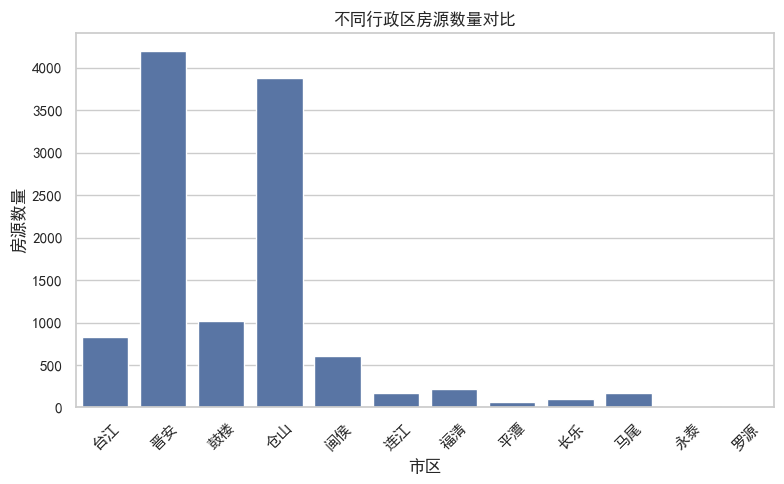

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="市区")
plt.title("不同行政区房源数量对比")
plt.xlabel("市区")
plt.ylabel("房源数量")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- **结论**：晋安、仓山房源量遥遥领先（均接近/超过4000套），是福州二手房供给核心区域；鼓楼、台江、闽侯为中等水平；连江、平潭、罗源等远郊县域房源量极低，市场活跃度不足。整体呈现主城区集中、远郊分散的分布特征。

### 图表 2：各行政区平均单价柱状图

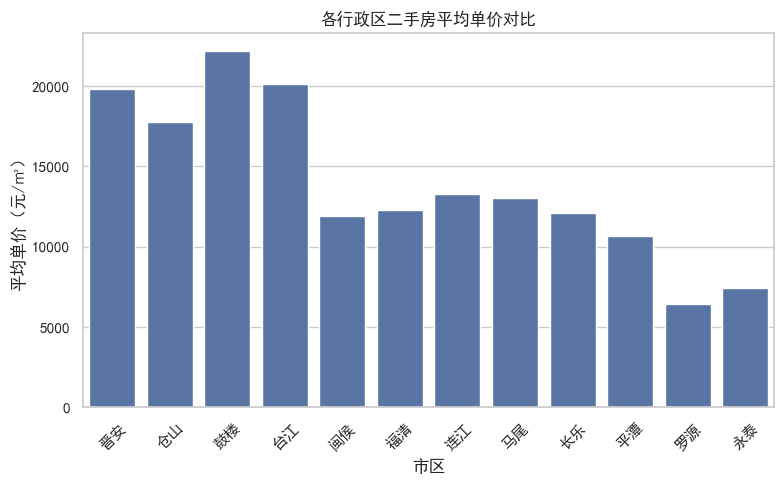

In [72]:
plt.figure(figsize=(8, 5))
sns.barplot(x=area_group["市区"], y=area_group["平均单价"])
plt.title("各行政区二手房平均单价对比")
plt.xlabel("市区")
plt.ylabel("平均单价（元/㎡）")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


- **结论**：鼓楼、台江、晋安、仓山均价遥遥领先，是福州二手房价格核心高地；连江、马尾、福清等近郊区域均价处于中等水平；罗源、永泰均价最低。整体呈现主城区房价高、远郊县域房价低的梯度分布特征。

### 图表 3：主流户型房源数量饼图

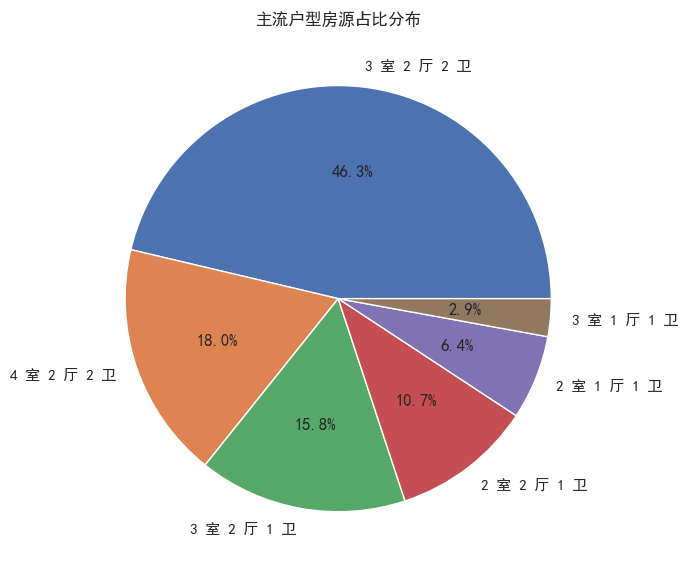

In [73]:
# 筛选房源量前6的主力户型
top_house = house_type_group.head(6)
plt.figure(figsize=(7,7))
plt.pie(top_house["房源套数"], labels=top_house["户型"], autopct="%1.1f%%")
plt.title("主流户型房源占比分布")
plt.tight_layout()
plt.show()


- **结论**：3室2厅2卫户型占比高达46.3%，是福州二手房绝对主力户型；4室2厅2卫、3室2厅1卫紧随其后，三房户型整体合计占比超80%。小户型和小配置户型占比较低，反映出市场流通房源以刚需改善三房为主。

### 图表 4：建造年份与房源均价关系散点图

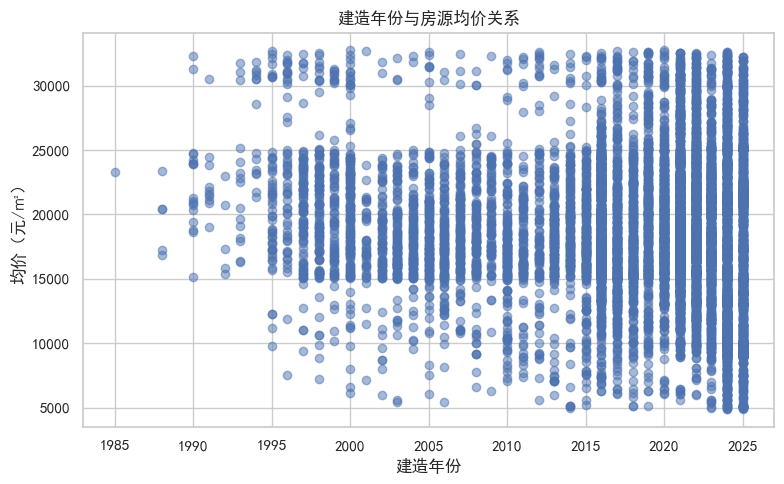

In [74]:
plt.figure(figsize=(8,5))
plt.scatter(data["建造年份"], data["均价最终值"], alpha=0.5)
plt.title("建造年份与房源均价关系")
plt.xlabel("建造年份")
plt.ylabel("均价（元/㎡）")
plt.tight_layout()
plt.show()


- **结论**：整体呈现建造年份越新，房源均价越高的趋势；老旧房源价格跨度大且低价房源占比多，2015年之后建成的次新房高价房源更为集中，房龄是影响二手房定价的重要因素。

## 8. 主要结论

### 8.1 核心发现
1. **房源供给区域集中**：晋安、仓山是福州二手房供给的核心区域，房源数量远高于其他行政区；鼓楼、台江供给量中等，罗源、永泰、平潭等远郊县域房源稀缺，市场活跃度偏低。
   （支持图表：行政区房源数量柱状图）

2. **房价呈圈层梯度分布**：鼓楼、台江、晋安、仓山四大主城区二手房均价处于第一梯队，价格水平最高；闽侯、福清、连江等近郊区域均价居中；罗源、永泰远郊县均价最低，整体呈现由市中心向外逐级递减的特征。
   （支持图表：行政区平均单价柱状图）

3. **主流户型以改善型三房为主**：3室2厅2卫户型占比达46.3%，是市场绝对主力；叠加3室2厅1卫、4室2厅2卫户型后，三房及以上改善户型合计占比超80%，小户型流通占比较小。
   （支持图表：主流户型房源占比饼图）

4. **房龄与房价显著正相关**：建造年份越新，房源均价整体越高；老旧房源价格跨度大且低价房源占比多，2015年之后建成的次新房高价房源更为集中，房龄是影响二手房定价的重要因素。
   （支持图表：建造年份与房源均价关系散点图）

### 8.2 数据局限与结论说明
1. 本次分析仅使用平台挂牌房源数据，未包含实际成交价格，挂牌价与真实成交价存在差异，对房价盈利水平的结论需谨慎参考。
2. 数据未细分楼盘配套、学区、楼层等变量，同一行政区内部楼盘价格存在差异，区域均价仅代表整体水平，不能直接套用至单个楼盘。
3. 远郊县域房源样本量较少，可能导致价格、户型结构统计存在轻微偏差，小众区域的分析结论仅作宏观参考。
